<a href="https://colab.research.google.com/github/thesamokoosi/CodVeda-Data-Analytics-Internship/blob/main/Level2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Level 2  
**Tasks Completed:** Task 1 (Regression Analysis) & Task 2 (Time Series Analysis)  
**Datasets:** Housing Prediction Dataset & Stock Prices Dataset

## Introduction
In this notebook, we will build a Simple Linear Regression model to predict housing prices and perform a Time Series Analysis on stock market data to detect trends and seasonality.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Statsmodels for Time Series
from statsmodels.tsa.seasonal import seasonal_decompose

# Set a clean style for all visualizations
sns.set_theme(style="whitegrid")

---
## Task 1: Regression Analysis (Housing Dataset)
**Objective:** Perform a simple linear regression analysis to predict house prices based on the number of rooms.

### 1. Data Loading and Preprocessing
The housing dataset lacks column headers, so we will assign the standard Boston Housing column names. We will focus on `RM` (Average Number of Rooms) as our independent variable (X) and `MEDV` (Median Value/Price) as our dependent variable (Y).

In [12]:
# Load Housing Data
# Since the raw file has no headers, we specify header=None and assign standard names
#column_names =['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df_house = pd.read_csv('Housing Dataset.csv')

print("--- Housing Data Overview ---")
display(df_house.head())

# Define X (Predictor: Number of rooms) and y (Target: Median Value)
X = df_house[['RM']]  # Must be a 2D array for scikit-learn
y = df_house['MEDV']

--- Housing Data Overview ---


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,222,18.7,NaN,36.2


### 2. Model Training and Evaluation
We will split the data into training (80%) and testing (20%) sets, fit the model, and evaluate its performance using Mean Squared Error (MSE) and the R-squared metric.

--- Regression Model Evaluation ---
Coefficient (Slope): 9.3483
Intercept: -36.2463
Mean Squared Error (MSE): 46.1448
R-squared: 0.3708


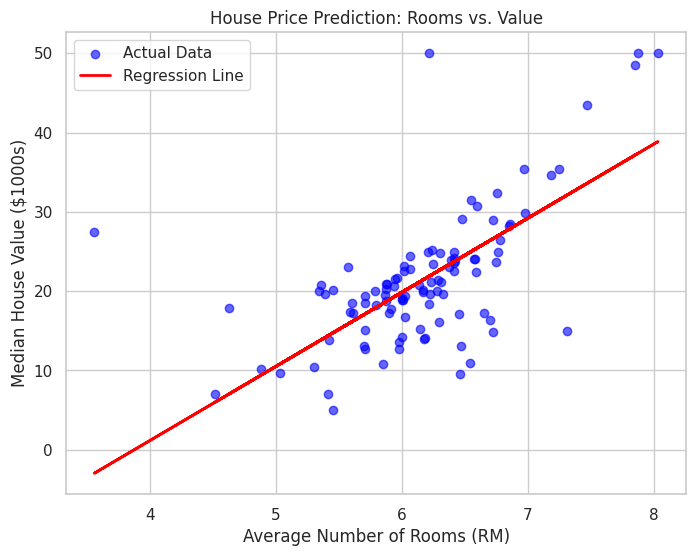

In [13]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the simple linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("--- Regression Model Evaluation ---")
print(f"Coefficient (Slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")

# Visualize the regression line
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('House Price Prediction: Rooms vs. Value')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Median House Value ($1000s)')
plt.legend()
plt.show()

---
## Task 2: Time Series Analysis (Stock Prices Dataset)
**Objective:** Analyze a time-series dataset to detect trends and seasonality using moving averages and decomposition.

### 1. Data Loading and Plotting
We will load the stock prices data, filter the data to focus on a single stock (e.g., Apple - `AAPL`), and set the `date` as our time-series index.

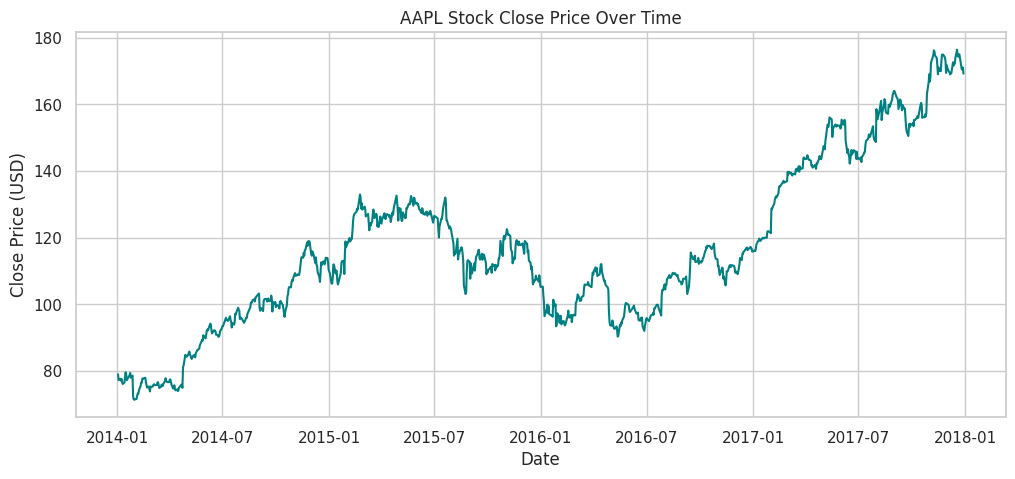

In [14]:
# Load Stock Data
df_stock = pd.read_csv('2) Stock Prices Data Set.csv')

# Convert the 'date' column to datetime objects
df_stock['date'] = pd.to_datetime(df_stock['date'])

# Filter for Apple ('AAPL') stock to create a single continuous time series
aapl_df = df_stock[df_stock['symbol'] == 'AAPL'].copy()

# Set 'date' as the index and sort it chronologically
aapl_df.set_index('date', inplace=True)
aapl_df.sort_index(inplace=True)

# Plot the raw time-series data
plt.figure(figsize=(12, 5))
plt.plot(aapl_df.index, aapl_df['close'], color='teal')
plt.title('AAPL Stock Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.show()

### 2. Time Series Decomposition & Moving Average Smoothing
We will decompose the `close` price into its Trend, Seasonality, and Residual components. Finally, we will apply a 30-day Moving Average (MA) to smooth out the noise and visualize the core trend.

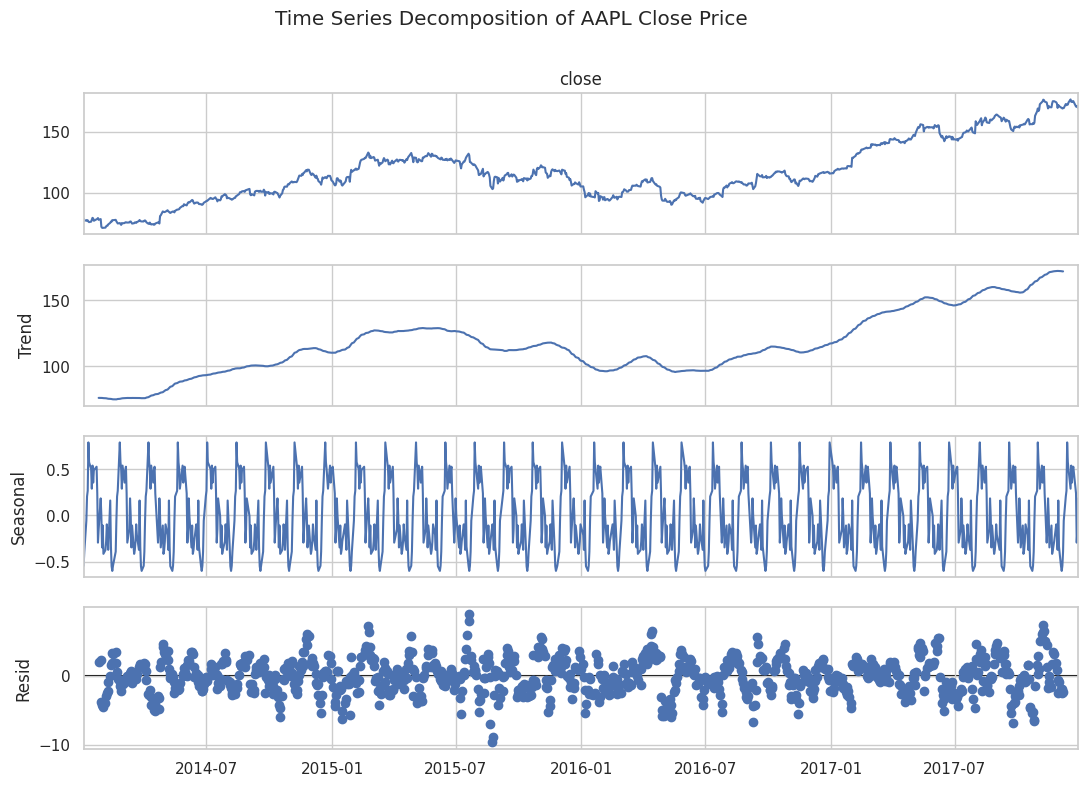

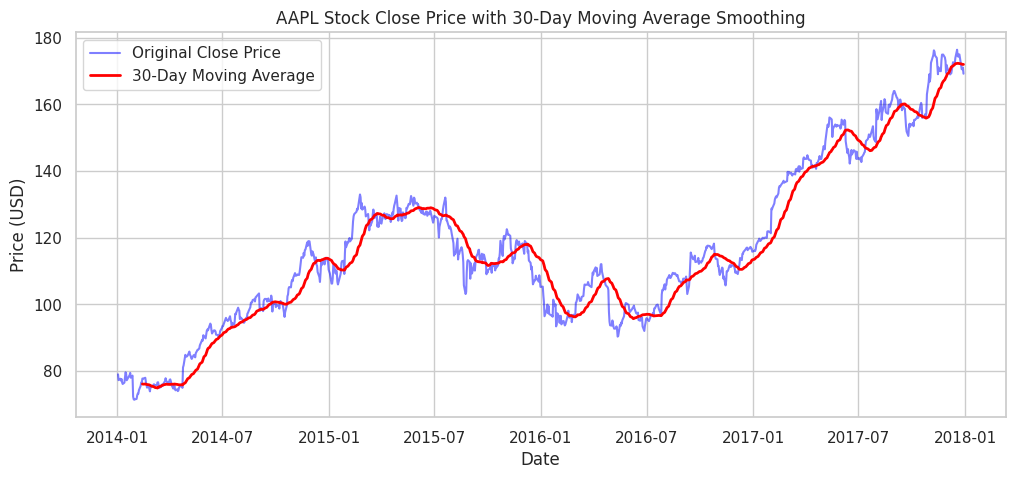

In [ ]:
# 1. Decompose the series using statsmodels
# We use a period of 30 to represent roughly a month of trading data
decomposition = seasonal_decompose(aapl_df['close'], model='additive', period=30)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Time Series Decomposition of AAPL Close Price', y=1.02)
plt.show()

# 2. Perform moving average smoothing (30-day window)
aapl_df['MA_30'] = aapl_df['close'].rolling(window=30).mean()

# 3. Plot the results
plt.figure(figsize=(12, 5))
plt.plot(aapl_df.index, aapl_df['close'], label='Original Close Price', alpha=0.5, color='blue')
plt.plot(aapl_df.index, aapl_df['MA_30'], label='30-Day Moving Average', color='red', linewidth=2)
plt.title('AAPL Stock Close Price with 30-Day Moving Average Smoothing')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()